# Oracle tuning & calibration — with AutoEIS EIS + ECM

This notebook calibrates a `PyBaMMOracle` to target EIS/capacity behaviour using
the **real AutoEIS Bayesian ECM fit** (`_autoeis_ecm`), not the fast Randles stub.

> **Runtime / requirements.** This notebook is **slow** (PyBaMM SPMe cycles +
> AutoEIS/NumPyro Bayesian inference + an Optuna search). It needs the extras:
>
> ```bash
> uv sync --extra autoeis --extra tune
> ```
>
> It is committed with outputs pre-rendered and is **not** executed in CI or on
> the docs builder. Re-run it manually to refresh the figures.

**What it shows**
1. One real EIS spectrum from AutoEIS's own bundled battery-cycling dataset,
   fit with AutoEIS (Nyquist + posterior).
2. A calibration against that same real dataset: fit a subsample of its cycles
   to get target arc-ratio/R1-growth metrics, then recover matching
   degradation scales with `calibrate_oracle`.
3. Deeper diagnostics — EIS before/after tuning, the Optuna Pareto frontier, the
   convergence trace, and how the **degradation-mechanism mix** shifts during tuning.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import optuna
import autoeis as ae

from battery_oracle import (
    PyBaMMOracle, make_pybamm_candidates, compute_real_targets,
    write_oracle_config, load_default_ecm_circuit,
)
from battery_oracle.oracle import _autoeis_ecm, _AUTOEIS_AVAILABLE
from battery_oracle.tune import run_oracle_candidate
from battery_oracle._plotting import slipstream, label_axes

optuna.logging.set_verbosity(optuna.logging.WARNING)

assert _AUTOEIS_AVAILABLE, "This notebook needs the [autoeis] extra: uv sync --extra autoeis --extra tune"

plt.rcParams.update({"font.family": "serif", "figure.dpi": 120, "axes.grid": True,
                     "grid.alpha": 0.3})

def cmap_colors(n):
    """n evenly spaced Slipstream colours."""
    return [slipstream(i / max(n - 1, 1)) for i in range(n)]

# The ECM structure is NOT assumed here: it is loaded from the YAML config
# (config_oracle_defaults.yml -> ecm.circuit). Every oracle below fits this circuit,
# and the tune engine derives the ohmic/arc-resistor positions from it. It also
# happens to be the exact circuit AutoEIS's own bundled battery dataset (below)
# is fit with in AutoEIS's documentation.
CIRCUIT = load_default_ecm_circuit()
print("ECM circuit (from config):", CIRCUIT)

# EIS noise. The default "combined" model adds 1/f (flicker) noise whose amplitude
# scales as noise_level*|Z|/sqrt(freq) -- it blows up at low frequencies (~10x more
# noise at 0.01 Hz than at 1 Hz). For clean demonstration spectra we use flat
# "white" noise at a modest level; switch to "combined"/"flicker" to see the
# realistic low-frequency scatter, or raise eis.freq_min_hz to drop the noisiest
# decade. See the EIS-noise discussion in the docs.
EIS_NOISE = dict(eis_noise_model="white", eis_noise_level=0.01)


ECM circuit (from config): R1-P2-[R3,P4]-[R5,P6]


## 1. One real EIS spectrum, fit with AutoEIS

`autoeis` ships a real dataset as part of the package itself:
`ae.io.load_battery_dataset()` returns 130 EIS spectra measured on a real coin
cell at the discharged state across cycling — it's AutoEIS's own example
dataset for per-cycle batch inference, and it happens to be fit with the exact
circuit (`R1-P2-[R3,P4]-[R5,P6]`) this project defaults to. Pull one cycle and
fit it with `_autoeis_ecm` directly (no oracle/PyBaMM involved in this section).


In [2]:
battery_cycles = ae.io.load_battery_dataset()
print(f"AutoEIS bundled battery dataset: {len(battery_cycles)} real coin-cell "
      f"EIS cycles (discharged state)")

freq, Z = battery_cycles[0]
freq = freq.real                 # stored as complex128 with zero imaginary part
Zr, nImZ = Z.real, -Z.imag       # jones2022 Nyquist convention: x=Re Z, y=-Im Z

diag = {}
_autoeis_ecm(freq, Zr, Z.imag, circuit=CIRCUIT, _diag=diag)
print("fitted ECM elements:", diag["ecm_params"])
print("posterior max CV:", diag["max_cv"], " converged:", diag["converged"])


AutoEIS bundled battery dataset: 130 real coin-cell EIS cycles (discharged state)


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

fitted ECM elements: {'elements': ['R1', 'P2w', 'P2n', 'R3', 'P4w', 'P4n', 'R5', 'P6w', 'P6n'], 'values': {'R1': 0.11546773037851694, 'P2w': 17.46998294924039, 'P2n': 0.7937539199752672, 'R3': 1.173976231810725, 'P4w': 0.06456656867804078, 'P4n': 0.5016158910157633, 'R5': 0.40648528958005964, 'P6w': 0.13569317554032054, 'P6n': 0.9961053028936737}}
posterior max CV: 0.05553713127620624  converged: True


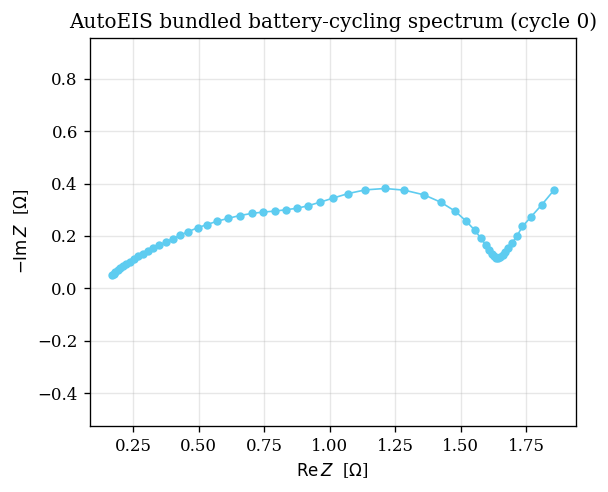

In [3]:
# Nyquist of the real spectrum (jones2022 convention: x=Re Z, y=-Im Z)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(Zr, nImZ, "o-", color=slipstream(0.15), ms=4, lw=1)
ax.set_xlabel(r"$\mathrm{Re}\,Z$  [$\Omega$]")
ax.set_ylabel(r"$-\mathrm{Im}\,Z$  [$\Omega$]")
ax.set_title("AutoEIS bundled battery-cycling spectrum (cycle 0)")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()


### AutoEIS Bayesian fit + posterior

Refit the same real spectrum directly with `_autoeis_ecm`, keeping the raw MCMC
samples so we can plot the posterior for the key elements.


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

elements: ['R1', 'R2', 'P3w', 'P3n', 'R4', 'P5w', 'P5n']
median values: {'R1': 0.1074, 'R2': 1.7488, 'P3w': 0.0987, 'P3n': 0.4557, 'R4': 2.8725, 'P5w': 32.1576, 'P5n': 0.9807}


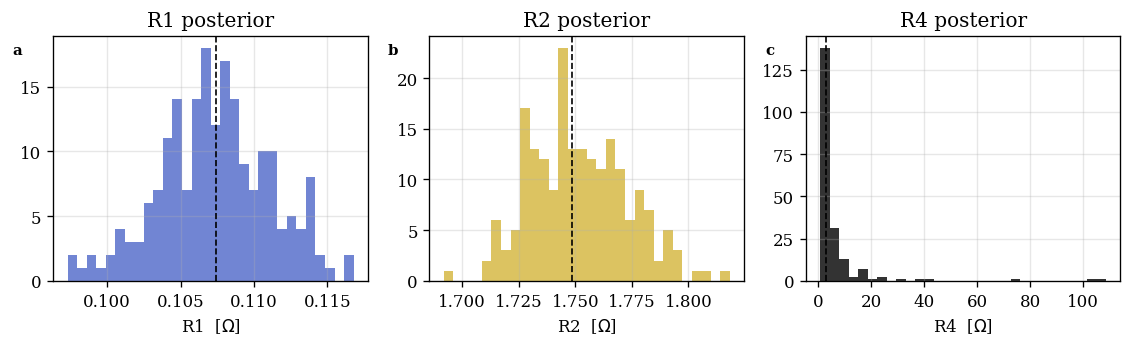

In [4]:
diag = {}
vec, samples, variables = _autoeis_ecm(freq, Zr, -nImZ, _diag=diag, return_samples=True)
elems = diag["ecm_params"]["elements"]
vals = diag["ecm_params"]["values"]
print("elements:", elems)
print("median values:", {k: round(v, 4) for k, v in vals.items()})

# Posterior distributions for the ohmic + charge-transfer resistors
res_keys = [k for k in variables if k.startswith("R")]
cols = cmap_colors(len(res_keys))
fig, axes = plt.subplots(1, len(res_keys), figsize=(3.2 * len(res_keys), 3))
for ax, k, c in zip(np.atleast_1d(axes), res_keys, cols):
    ax.hist(np.asarray(samples[k]), bins=30, color=c, alpha=0.8)
    ax.axvline(np.median(samples[k]), color="k", ls="--", lw=1)
    ax.set_title(f"{k} posterior"); ax.set_xlabel(f"{k}  [$\Omega$]")
label_axes(np.atleast_1d(axes))
plt.tight_layout()


## 2. Real calibration targets from AutoEIS's bundled dataset

An earlier version of this notebook built the calibration cache by replaying
the oracle against itself — a self-consistency demo. That made "recovery"
tautological, and combined badly with a search space that (correctly, for real
cells) excludes the oracle's own default scale: the tuned result ended up
*worse* than doing nothing. Using AutoEIS's own bundled `battery_data.npy`
instead makes this a fit against a **genuine external measurement**.

Fitting all 130 real cycles with full Bayesian AutoEIS inference is too slow
for a demo notebook, so we fit an evenly spaced subsample spanning the first to
the last cycle — enough to see the R1-growth trend — and feed those fits to
`compute_real_targets`. A separate, lightweight cache of synthetic protocols
(`sim_cache`) drives the candidate oracle runs in §3 onward: the real dataset
has measured spectra but no recorded charge/discharge protocol to replay, so
the oracle side still exercises its own representative cycling.


In [5]:
N_REAL_CYCLES = 8
real_idx = np.linspace(0, len(battery_cycles) - 1, N_REAL_CYCLES).astype(int)

real_cache = {"cell_id": "autoeis_battery_dataset", "circuit": CIRCUIT,
              "cycles": [], "data": {}}
for i in real_idx:
    freq_i, Z_i = battery_cycles[int(i)]
    ecm = _autoeis_ecm(freq_i.real, Z_i.real, Z_i.imag, circuit=CIRCUIT)
    key = str(int(i))
    real_cache["cycles"].append(key)
    real_cache["data"][key] = {"ecm_charge": [float(x) for x in ecm]}

targets = compute_real_targets(real_cache)
print(f"fitted {len(real_idx)}/{len(battery_cycles)} real cycles "
      f"(indices {[int(i) for i in real_idx]})")
print("targets (from AutoEIS's real coin-cell dataset):", targets)

# cache carries the circuit so calibrate_oracle/run_oracle_candidate read the
# ECM layout from it rather than assuming a fixed structure.
cands = make_pybamm_candidates(n_candidates=4)
sim_cache = {"real_cell_capacity_mah": 200.0, "circuit": CIRCUIT,
             "cycles": [str(i) for i in range(len(cands))],
             "data": {str(i): {"protocol": [float(x) for x in p]}
                      for i, p in enumerate(cands)}}


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

fitted 8/130 real cycles (indices [0, 18, 36, 55, 73, 92, 110, 129])
targets (from AutoEIS's real coin-cell dataset): {'mean_arc_ratio': 16.523579342665965, 'r1_growth_pct': 34.98254364354434}


## 3. Multi-objective calibration (NSGA-II)

Arc-ratio error and R1-growth error are **competing** objectives — lowering one can
raise the other — so instead of collapsing them into one weighted score we run a
genuine **multi-objective** optimisation with Optuna's NSGA-II sampler, minimising
both simultaneously over the four degradation scales. The result is a **Pareto
front**: the set of non-dominated trade-off solutions. `n_trials` is modest for
runtime (each trial replays the whole cache through an AutoEIS oracle).


In [6]:
scale_space = {
    "kinetics_scale":      (0.10, 0.50),
    "sei_rate_scale":      (0.01, 1.00),
    "dead_li_decay_scale": (0.10, 1000.0),
    "plating_rate_scale":  (0.01, 10.0),
}
scale_names = list(scale_space)
arc_t = targets["mean_arc_ratio"]; r1_t = targets["r1_growth_pct"]
trial_results = {}   # trial.number -> full run_oracle_candidate dict (for provenance)

def mo_objective(trial):
    scales = {n: trial.suggest_float(n, lo, hi, log=True) for n, (lo, hi) in scale_space.items()}
    res = run_oracle_candidate(sim_cache, scales["kinetics_scale"], scales["sei_rate_scale"],
                               scales["dead_li_decay_scale"], scales["plating_rate_scale"],
                               "accelerated", False, circuit=CIRCUIT)
    trial_results[trial.number] = res
    arc, r1 = res["oracle_arc_ratio"], res["oracle_r1_growth_pct"]
    # Two objectives to MINIMISE simultaneously; large penalty for invalid fits.
    arc_err = abs(arc - arc_t) if arc is not None else 1e3
    r1_err  = abs(r1  - r1_t)  if r1  is not None else 1e3
    return arc_err, r1_err

study = optuna.create_study(
    directions=["minimize", "minimize"],           # <- genuine multi-objective
    sampler=optuna.samplers.NSGAIISampler(seed=42, population_size=8),
)
study.optimize(mo_objective, n_trials=24, show_progress_bar=False)

pareto = study.best_trials                          # Optuna's true non-dominated set
print(f"{len(study.trials)} trials evaluated; {len(pareto)} on the Pareto front")

# A single representative solution: the knee of the front (min L1 of the two
# min-max-normalised objectives). Used for the before/after EIS and the config.
def knee_of(trials):
    V = np.array([t.values for t in trials], float)
    N = (V - V.min(0)) / (np.ptp(V, 0) + 1e-12)
    return trials[int(np.argmin(N.sum(1)))]
knee = knee_of(pareto)
knee_scales = {n: knee.params[n] for n in scale_names}
print("knee scales:", {k: round(v, 4) for k, v in knee_scales.items()},
      " objectives (arc_err, r1_err):", [round(v, 4) for v in knee.values])


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


Generating impedance integral lookups...
Generating response integral lookups...
Integral lookups ready


Computing DRT ...: 100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

...

Generating impedance integral lookups...
Generating response integral lookups...
Integral lookups ready


Computing DRT ...: 100%|██████████| 1/1 [00:01<00:00,  1.24s/it]


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

24 trials evaluated; 4 on the Pareto front
knee scales: {'kinetics_scale': 0.4761, 'sei_rate_scale': 0.3718, 'dead_li_decay_scale': 0.6291, 'plating_rate_scale': 0.082}  objectives (arc_err, r1_err): [5.8036, 3.1235]


## 4. EIS spectra before vs after tuning

Run the oracle at the **default** scales `(1,1,1,1)` and at the Pareto **knee**
scales over `sim_cache`'s protocols, and overlay the resulting Nyquist spectra
against a real AutoEIS-measured spectrum. The real coin cell and the
Chen2020-parameterised SPMe are very different cell formats/scales, so each
spectrum is normalised by its own fitted ohmic resistance R1 before plotting —
that's exactly the scale-invariant arc-ratio quantity being calibrated, and it
avoids a meaningless absolute-Ω comparison between an automotive pouch cell and
a coin cell. This is the visual payoff of the calibration.


In [7]:
def run_spectra(scales):
    o = PyBaMMOracle(ecm_model_fn=_autoeis_ecm, degradation_preset="accelerated",
                     capacity_check=False, real_cell_capacity_mah=sim_cache["real_cell_capacity_mah"],
                     circuit=CIRCUIT, **EIS_NOISE, **scales)
    o.reset()
    specs = []
    for key in sim_cache["cycles"]:
        try:
            o(np.array(sim_cache["data"][key]["protocol"]))
        except Exception:
            break
        hh = o._history[-1]
        specs.append((hh["Z_charge_real"], hh["Z_charge_neg_imag"], hh["ecm_params_charge"][0]))
    return specs

default_scales = {n: 1.0 for n in scale_names}
spec_default = run_spectra(default_scales)
spec_tuned = run_spectra(knee_scales)


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


Generating impedance integral lookups...
Generating response integral lookups...
Integral lookups ready


Computing DRT ...: 100%|██████████| 1/1 [00:00<00:00,  1.07it/s]


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

...

[PyBaMMOracle] call 3: raw_protocol=[140.   70.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 3.5000 A for 900 seconds or until 4.3 V', 'Charge at 1.7500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


Generating impedance integral lookups...
Generating response integral lookups...
Integral lookups ready


Computing DRT ...: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it]


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

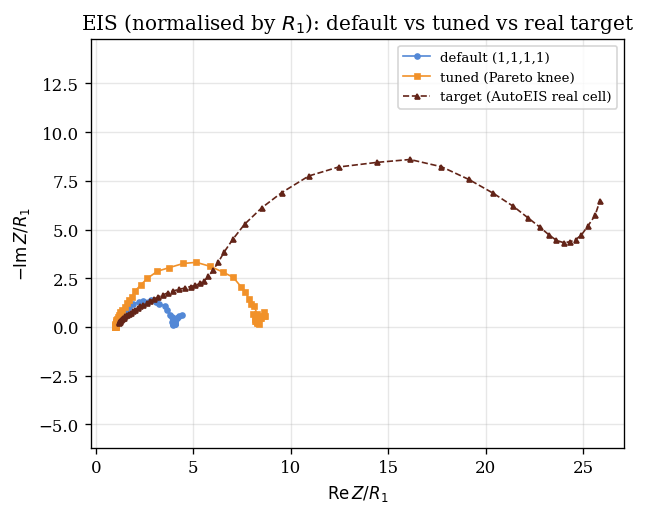

In [8]:
# Overlay the last-cycle Nyquist for default vs tuned-knee, each normalised by
# its own R1 (ohmic resistance), against a real AutoEIS-measured spectrum.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
if spec_default:
    Zr_d, nZi_d, r1_d = spec_default[-1]
    ax.plot(np.array(Zr_d) / r1_d, np.array(nZi_d) / r1_d, "o-", color=slipstream(0.05),
            ms=3, lw=1, label="default (1,1,1,1)")
if spec_tuned:
    Zr_t, nZi_t, r1_tuned = spec_tuned[-1]
    ax.plot(np.array(Zr_t) / r1_tuned, np.array(nZi_t) / r1_tuned, "s-", color=slipstream(0.55),
            ms=3, lw=1, label="tuned (Pareto knee)")

real_key = str(int(real_idx[-1]))
_, Z_real_last = battery_cycles[int(real_idx[-1])]
r1_real = real_cache["data"][real_key]["ecm_charge"][0]     # R1 is element 0 for CIRCUIT
ax.plot(Z_real_last.real / r1_real, -Z_real_last.imag / r1_real, "^--",
        color=slipstream(0.9), ms=3, lw=1, label="target (AutoEIS real cell)")

ax.set_xlabel(r"$\mathrm{Re}\,Z / R_1$"); ax.set_ylabel(r"$-\mathrm{Im}\,Z / R_1$")
ax.set_title("EIS (normalised by $R_1$): default vs tuned vs real target"); ax.legend(fontsize=8)
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()


## 5. The real Pareto front

Every trial in the two-objective plane (arc-ratio error vs R1-growth error), with
the **true non-dominated set** returned by NSGA-II (`study.best_trials`) drawn as the
front and the knee marked. Optuna also ships
`optuna.visualization.matplotlib.plot_pareto_front(study)` for the same view.


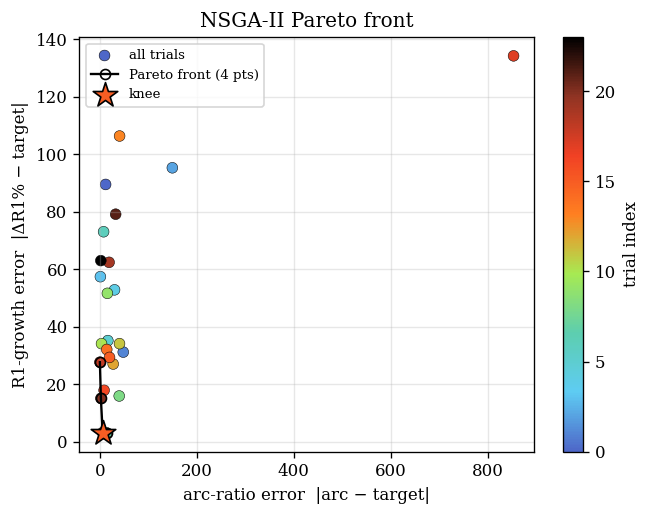

In [9]:
all_v = np.array([t.values for t in study.trials], float)
pf = np.array([t.values for t in pareto], float)
pf = pf[np.argsort(pf[:, 0])]
order = np.array([t.number for t in study.trials])

fig, ax = plt.subplots(figsize=(5.6, 4.4))
sc = ax.scatter(all_v[:, 0], all_v[:, 1], c=order, cmap=slipstream, s=42, edgecolor="k", lw=0.3,
                label="all trials")
ax.plot(pf[:, 0], pf[:, 1], "-o", color="k", lw=1.4, ms=6, mfc="none",
        label=f"Pareto front ({len(pf)} pts)")
ax.scatter([knee.values[0]], [knee.values[1]], marker="*", s=240, color=slipstream(0.65),
           edgecolor="k", zorder=5, label="knee")
ax.set_xlabel("arc-ratio error  |arc − target|")
ax.set_ylabel("R1-growth error  |ΔR1% − target|")
ax.set_title("NSGA-II Pareto front"); ax.legend(fontsize=8)
fig.colorbar(sc, ax=ax, label="trial index")
plt.tight_layout()


## 6. Convergence — hypervolume

For a multi-objective search the natural convergence metric is the **hypervolume**
dominated by the running Pareto front (relative to a fixed reference point): it grows
as the front expands toward the origin. We also show each objective's running best.


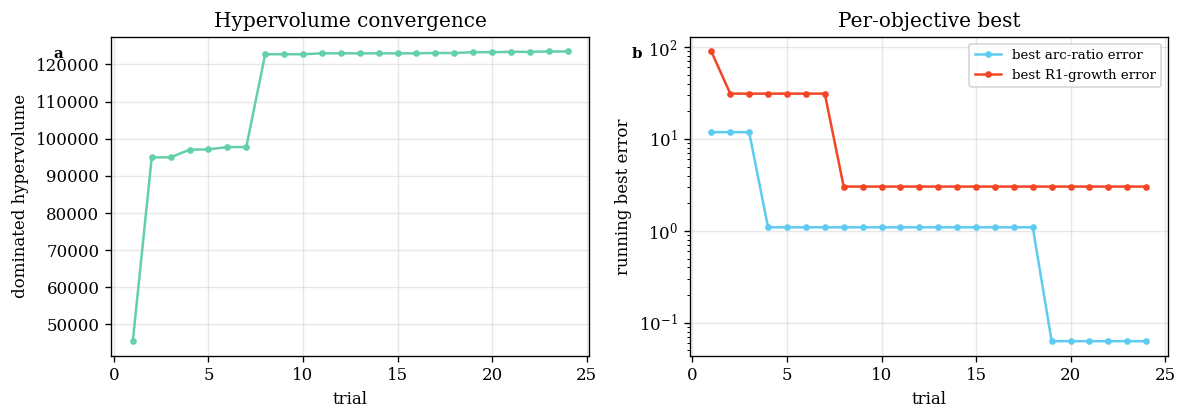

In [10]:
def nondominated(P):
    P = np.asarray(P, float); keep = np.ones(len(P), bool)
    for i, p in enumerate(P):
        if np.any(np.all(P <= p, axis=1) & np.any(P < p, axis=1)):
            keep[i] = False
    return P[keep]

def hv2d(front, ref):
    F = nondominated(front)
    F = F[(F[:, 0] <= ref[0]) & (F[:, 1] <= ref[1])]
    if len(F) == 0:
        return 0.0
    F = F[np.argsort(F[:, 0])]
    xs = np.append(F[:, 0], ref[0]); area = 0.0
    for i in range(len(F)):
        area += (xs[i + 1] - xs[i]) * (ref[1] - F[i, 1])
    return area

ref = all_v.max(0) * 1.05                          # reference point (worst corner)
hv_hist = [hv2d(all_v[:t + 1], ref) for t in range(len(all_v))]
run_min0 = np.minimum.accumulate(all_v[:, 0])
run_min1 = np.minimum.accumulate(all_v[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(range(1, len(hv_hist) + 1), hv_hist, "-o", color=slipstream(0.3), ms=3)
axes[0].set_xlabel("trial"); axes[0].set_ylabel("dominated hypervolume")
axes[0].set_title("Hypervolume convergence")
axes[1].plot(range(1, len(all_v) + 1), run_min0, "-o", ms=3, color=slipstream(0.15),
             label="best arc-ratio error")
axes[1].plot(range(1, len(all_v) + 1), run_min1, "-o", ms=3, color=slipstream(0.7),
             label="best R1-growth error")
axes[1].set_yscale("log"); axes[1].set_xlabel("trial"); axes[1].set_ylabel("running best error")
axes[1].set_title("Per-objective best"); axes[1].legend(fontsize=8)
label_axes(axes)
plt.tight_layout()


## 7. Degradation-mechanism shift across the Pareto front

The trade-off is physical: the arc-ratio-optimal end of the front and the
R1-growth-optimal end reach their fits with a **different mechanism mix**. For the two
front extremes and the knee, re-run the oracle and read the cumulative capacity loss
by mechanism (`cumulative_sei_loss_ah`, `cumulative_plating_ah`,
`cumulative_crack_sei_ah`, `cumulative_dod_lam_ah`).


In [11]:
pf_trials = sorted(pareto, key=lambda t: t.values[0])
picks = {
    "min arc-err": pf_trials[0],
    "knee": knee,
    "min R1-err": pf_trials[-1],
}
mech_keys = ["cumulative_sei_loss_ah", "cumulative_plating_ah",
             "cumulative_crack_sei_ah", "cumulative_dod_lam_ah"]

def mech_series(scales):
    o = PyBaMMOracle(ecm_model_fn=_autoeis_ecm, degradation_preset="accelerated",
                     capacity_check=False, real_cell_capacity_mah=sim_cache["real_cell_capacity_mah"],
                     circuit=CIRCUIT, **{n: scales[n] for n in scale_names})
    o.reset()
    for key in sim_cache["cycles"]:
        try:
            o(np.array(sim_cache["data"][key]["protocol"]))
        except Exception:
            break
    last = o._history[-1] if o._history else {}
    return [abs(last.get(k, 0.0)) for k in mech_keys]


[PyBaMMOracle] call 0: raw_protocol=[ 68.   34.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 1.7000 A for 900 seconds or until 4.3 V', 'Charge at 0.8500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


Generating impedance integral lookups...
Generating response integral lookups...
Integral lookups ready


Computing DRT ...: 100%|██████████| 1/1 [00:00<00:00,  1.08it/s]


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

...

[PyBaMMOracle] call 3: raw_protocol=[140.   70.    1.    0.5 100.    1. ] steps=('Discharge at 2.5000 A for 3600 seconds or until 3.0 V', 'Rest for 1200 seconds', 'Charge at 3.5000 A for 900 seconds or until 4.3 V', 'Charge at 1.7500 A for 900 seconds or until 4.3 V', 'Rest for 1200 seconds')


Generating impedance integral lookups...
Generating response integral lookups...
Integral lookups ready


Computing DRT ...: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s]


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

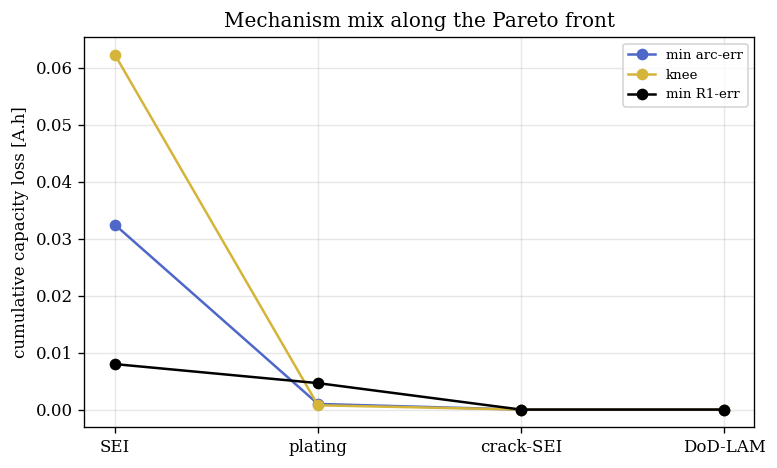

In [14]:

fig, ax = plt.subplots(figsize=(6.6, 4))
labels = ["SEI", "plating", "crack-SEI", "DoD-LAM"]
x = np.arange(len(mech_keys))
cols = cmap_colors(len(picks))
for (name, t), c in zip(picks.items(), cols):
    ax.plot(x, mech_series(t.params), "o-", color=c, label=name)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("cumulative capacity loss [A.h]")
ax.set_title("Mechanism mix along the Pareto front")
ax.legend(fontsize=8)
plt.tight_layout()


## 8. Persist a chosen solution

There is no single "best" in a multi-objective run — the Pareto front is a set of
valid trade-offs. Here we persist the **knee** point (a balanced compromise) with
`write_oracle_config`, passing every trial as provenance.


In [13]:
best_result = trial_results[knee.number]
all_results = [trial_results[t.number] for t in study.trials if t.number in trial_results]
write_oracle_config("config_oracle_demo.yml", "demo", "accelerated", real_cache["cell_id"],
                    len(real_cache["cycles"]), best_result, targets, all_results)
print("wrote config_oracle_demo.yml (knee point of the Pareto front)")


wrote config_oracle_demo.yml (knee point of the Pareto front)


## Assumptions & alternative outcomes

- **Genuine multi-objective front.** §3–§5 run NSGA-II with two separate objectives,
  so `study.best_trials` is a real non-dominated set. Picking the knee (§8) is one
  choice; a downstream user may prefer either extreme depending on whether arc-ratio
  or R1-growth matters more. NSGA-II is stochastic — the front depends on `seed`,
  `n_trials`, and `population_size`.
- **A real, if off-the-shelf, reference cell.** Targets come from
  `ae.io.load_battery_dataset()` — a real coin cell's measured EIS across
  cycling, fit with the same `_autoeis_ecm` pipeline the oracle uses — not from
  the oracle itself, so `calibrate_oracle`'s recovery here is a genuine fit
  rather than a tautology. It is AutoEIS's own bundled demo dataset though, not
  the jones2022 dataset `calibrate_oracle`'s own `kinetics_scale` bounds
  (`(0.10, 0.50)`) were calibrated against, so treat the resulting fit as a
  demonstration of the machinery rather than a validated jones2022-quality
  calibration. Only `N_REAL_CYCLES` (8) of the 130 real cycles are fit —
  Bayesian AutoEIS inference on all 130 would be far too slow for a demo notebook.
- **Parameter identifiability.** Several scale combinations sit near the same point on
  the front (e.g. `dead_li_decay_scale` vs `plating_rate_scale` both affect R1
  growth), so a front point maps to a *region* of scale space, not a unique setting.
- **Disabled mechanisms.** Particle cracking is off in all presets (a PyBaMM OCP
  regression — see the numerical-stability docs), so the crack-SEI channel in §7 is
  typically ~0; C-rate sensitivity comes from lithium plating instead.
- **Single-arc fidelity.** The SPMe model resolves one dominant charge-transfer arc,
  so the R5 arc is only weakly identifiable — expect the tuned arc-ratio to match the
  target better than the individual R3/R5 split.
